In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from matplotlib import pyplot as plt

In [4]:
# load dataset
df = pd.read_csv('/content/drive/MyDrive/heart_diseasis')
print(df.head())

   id  age     sex    dataset  ...        slope   ca               thal num
0   1   63    Male  Cleveland  ...  downsloping  0.0       fixed defect   0
1   2   67    Male  Cleveland  ...         flat  3.0             normal   2
2   3   67    Male  Cleveland  ...         flat  2.0  reversable defect   1
3   4   37    Male  Cleveland  ...  downsloping  0.0             normal   0
4   5   41  Female  Cleveland  ...    upsloping  0.0             normal   0

[5 rows x 16 columns]


In [5]:
df.shape

(920, 16)

In [6]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [7]:
df = df.select_dtypes(exclude=['object'])
print(df.head())

   id  age  trestbps   chol  thalch  oldpeak   ca  num
0   1   63     145.0  233.0   150.0      2.3  0.0    0
1   2   67     160.0  286.0   108.0      1.5  3.0    2
2   3   67     120.0  229.0   129.0      2.6  2.0    1
3   4   37     130.0  250.0   187.0      3.5  0.0    0
4   5   41     130.0  204.0   172.0      1.4  0.0    0


In [8]:
x=df.drop('num',axis=1)
y=df['num']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train)

      id  age  trestbps   chol  thalch  oldpeak   ca
880  881   62       NaN  170.0   120.0      3.0  NaN
457  458   54     150.0    NaN   122.0      0.0  NaN
797  798   51       NaN  339.0     NaN      NaN  NaN
25    26   50     120.0  219.0   158.0      1.6  0.0
84    85   52     120.0  325.0   172.0      0.2  0.0
..   ...  ...       ...    ...     ...      ...  ...
106  107   59     140.0  177.0   162.0      0.0  1.0
270  271   61     140.0  207.0   138.0      1.9  1.0
860  861   75     160.0  310.0   112.0      2.0  NaN
435  436   53     140.0  216.0   142.0      2.0  NaN
102  103   57     128.0  303.0   159.0      0.0  1.0

[736 rows x 7 columns]


In [12]:
clf_model=RandomForestClassifier()
clf_model.fit(x_train,y_train)

RandomForestClassifier()

In [13]:
y_pred=clf_model.predict(x_test)

In [14]:
y_pred

array([0, 0, 1, 1, 1, 0, 1, 3, 2, 2, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       3, 1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 3, 0, 1, 2, 1, 1, 0, 2, 0,
       0, 0, 2, 4, 0, 0, 1, 0, 0, 1, 0, 3, 1, 0, 2, 1, 0, 0, 3, 3, 1, 3,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 3, 0, 0, 0, 3, 2, 2,
       0, 0, 3, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 1, 1, 2, 0,
       0, 2, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 3, 0, 1, 0, 2, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 2, 1, 1, 1, 3, 1, 3, 1, 0, 2, 1, 1, 2, 1,
       0, 1, 0, 0, 3, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 2,
       0, 1, 1, 0, 2, 1, 0, 1])

In [15]:
y_test

,num
319,0
377,0
538,1
296,3
531,1
...,...
382,0
97,3
906,3
467,0


In [17]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[67  5  3  0  0]
 [17 30  6  1  0]
 [ 4 10  6  5  0]
 [ 5 11  3  6  1]
 [ 1  0  1  2  0]]


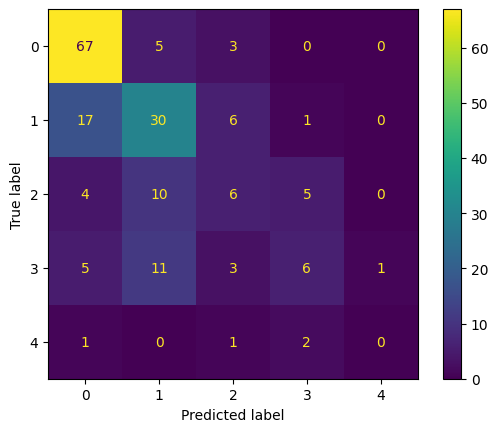

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.89      0.79        75
           1       0.54      0.56      0.55        54
           2       0.32      0.24      0.27        25
           3       0.43      0.23      0.30        26
           4       0.00      0.00      0.00         4

    accuracy                           0.59       184
   macro avg       0.40      0.38      0.38       184
weighted avg       0.55      0.59      0.56       184



   num  num_grouped
0    0            0
1    2            1
2    1            1
3    0            0
4    0            0
